# Exposure at operational priority 

**Purpose:** Link **exposure assets** (OSM vectors from notebook 03) to **daily operational priority** (ordinal rasters from notebook 05), and enrich analytics JSON for the dashboard and API.

This notebook answers operational questions such as:
- How many **roads / buildings / critical amenities** fall under High or Critical priority on a given date?
- How much **population** (GHSL) sits in each priority class?

**It does NOT recompute hazard, exposure or vulnerability** — it samples the outputs of notebook 06.

**Prerequisites:**
- `03_vuln_exp_download.ipynb` → `exposure/{roads,buildings,amenities}.geojson`
- `05_compute_operational_priority.ipynb` → `final_risk_maps/operational_priority_class_{date}.tif`
- `06` → `final_risk_analytics/analytics_{date}.json` (base metrics, enriched here)

**Outputs:**

| Output | Path | Consumer |
|--------|------|----------|
| Roads with daily priority | `exposure/roads_with_risk.geojson` | Map API, alerts |
| Buildings with daily priority | `exposure/buildings_with_risk.geojson` | Map API, alerts |
| Amenities with daily priority | `exposure/amenities_with_risk.geojson` | Map API, alerts |
| Enriched analytics | `final_risk_analytics/analytics_with_risk_{date}.json` | Analytics API |

**Priority values** in `risk` properties are **ordinal classes** (1–4), not continuous scores:
`1` Low · `2` Medium · `3` High · `4` Critical Priority

In [1]:
from glob import glob
import os
import geopandas as gpd
import rasterio
import numpy as np
import json
from tqdm import tqdm
from shapely.geometry import mapping
import rasterio.features
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import math

## Discover priority dates

List all `operational_priority_class_*.tif` files produced by notebook 06. Adjust the date filter to match the hazard stack you want to process (e.g. cut-off before a validation date).

In [4]:
path = '../data'

In [5]:
risk_maps = sorted(glob(f'{path}/final_risk_maps/operational_*.tif'))
dates = [os.path.basename(f).split('_')[-1].split('.')[0] for f in risk_maps]
dates = [d for d in dates if d <= "2025-08-22"]

# dates

## Roads — sample priority along network

For each road segment (LineString / MultiLineString), sample the **maximum** operational priority class under a small buffer (~50 m) for every date.

**Method:**
1. Buffer geometry by `buffer_dist` degrees (~50 m at this latitude)
2. Mask priority raster to buffered footprint
3. Take **max** class value (most severe priority touching the segment)
4. Store `{date: class}` dict in feature properties

**Output:** `exposure/roads_with_risk.geojson` — used by dashboard road layer and alert affected-road counts.

<Axes: >

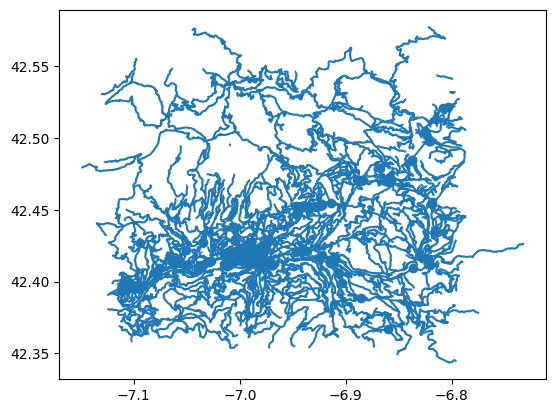

In [6]:
roads = gpd.read_file(f'{path}/exposure/roads.geojson')
roads.plot()

In [138]:
def compute_geojson_risk(geojson, output_path):
    buffer_dist = 0.0005  # ~50m, adjust as needed
    geojson_with_risk = {}
    for idx, row in geojson.iterrows():
        geom = row.geometry
        row_id = row["id"]
        # Only process lines, skip points
        if geom.geom_type not in ["LineString", "MultiLineString", "MultiPolygon", "Polygon"]:
            continue
        if row_id not in geojson_with_risk:
            geojson_with_risk[row_id] = {
                "geometry": mapping(geom),
                "risk": {},
            }
    # Now compute mean risk per date for each line
    for tif, date in zip(risk_maps, dates):
        print(date)
        with rasterio.open(tif) as src:
            def compute_risk(args):
                idx, row, buffer_dist, src_shape, src_transform, arr = args
                geom = row.geometry
                row_id = row["id"]
                if geom.geom_type not in ["LineString", "MultiLineString", "MultiPolygon", "Polygon"]:
                    return (row_id, None)
                buffered = geom.buffer(buffer_dist)
                mask = rasterio.features.geometry_mask(
                    [buffered], out_shape=src_shape, transform=src_transform, invert=True
                )
                values = arr[mask]
                # Remove NaN values from the array before calculating the max
                values = values[~np.isnan(values)]
                if len(values) > 0:
                    max_risk = float(np.max(values))
                    if math.isnan(max_risk): max_risk = 0
                else:
                    max_risk = None
                return (row_id, max_risk)
     
            arr = src.read(1, masked=True)
            src_shape = src.shape
            src_transform = src.transform
            tasks = [
                (idx, row, buffer_dist, src_shape, src_transform, arr)
                for idx, row in geojson.iterrows()
            ]
            with ThreadPoolExecutor() as executor:
                results = list(tqdm(executor.map(compute_risk, tasks), total=len(tasks)))
            for row_id, max_risk in results:
                if row_id not in geojson_with_risk:
                    continue  # Shouldn't happen, but for safety
                geojson_with_risk[row_id]["risk"][date] = max_risk
    # Build GeoJSON FeatureCollection
    features = []
    for road_id, data in geojson_with_risk.items():
        feature = {
            "type": "Feature",
            "properties": {
                "id": road_id,
                "risk": data["risk"],  # dict of date: mean_risk
            },
            "geometry": data["geometry"],
        }
        features.append(feature)
    road_geojson = {
        "type": "FeatureCollection",
        "features": features,
    }
    # Save to file
    with open(output_path, "w") as f:
        json.dump(road_geojson, f)

In [ ]:
compute_geojson_risk(roads, f"{path}/exposure/roads_with_risk.geojson")

2025-08-01


100%|██████████| 4865/4865 [00:12<00:00, 392.08it/s]


2025-08-02


100%|██████████| 4865/4865 [00:12<00:00, 384.49it/s]


2025-08-03


...

100%|██████████| 4865/4865 [00:12<00:00, 384.67it/s]


2025-08-21


100%|██████████| 4865/4865 [00:13<00:00, 373.42it/s]


2025-08-22


100%|██████████| 4865/4865 [00:12<00:00, 398.94it/s]


In [7]:
roads_with_risk = gpd.read_file(f'{path}/exposure/roads_with_risk.geojson')
# roads_with_risk

In [9]:
def plot_geojson_risk(geojson, date):
    # Function to extract risk for the current date
    def extract_risk(risk_dict, date):
        if isinstance(risk_dict, dict):
            return float(risk_dict.get(date, np.nan))
        else:
            return np.nan
    # Map risk values to colors, add np.nan as white
    risk_colors = {
        1.0: "green",
        2.0: "orange",
        3.0: "orange",
        4.0: "red",
    }
    # Add a column with the risk for the chosen date
    geojson['risk_value'] = geojson['risk'].apply(lambda r: extract_risk(r, date))
    # Assign 'white' where risk_value is nan
    def get_color(val):
        if np.isnan(val):
            return "white"
        return risk_colors.get(val, "white")
    geojson['color'] = geojson['risk_value'].apply(get_color)
    fig, ax = plt.subplots(figsize=(12, 8))
    geojson.plot(ax=ax, color=geojson['color'], linewidth=1.2)
    plt.title(f"Road Risk ({date})")
    plt.axis('off')
    plt.show()

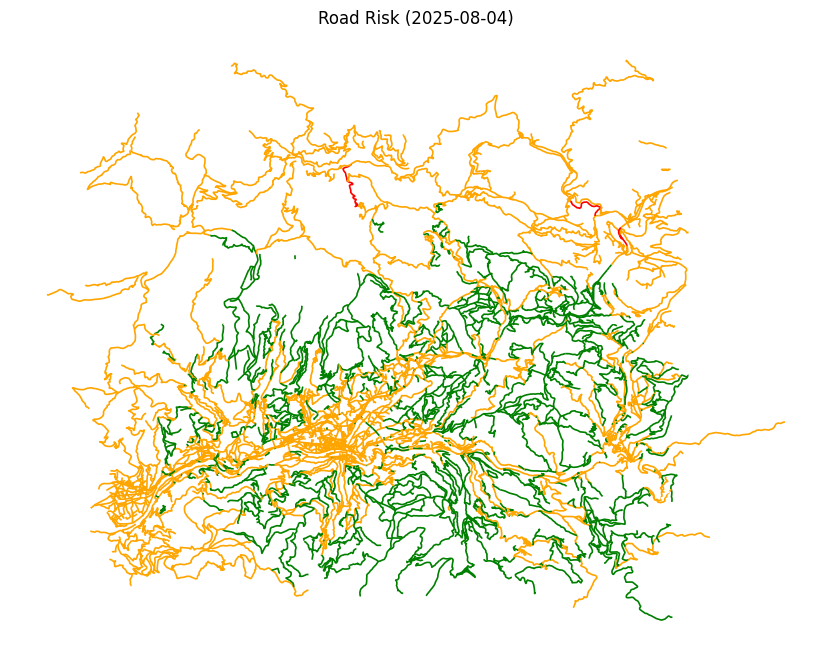

In [10]:
plot_geojson_risk(roads_with_risk, dates[3])

## Critical amenities — hospitals, schools, fire stations, etc.

Same sampling logic as roads. Critical facilities under High/Critical priority are key for operational messaging (evacuation, asset protection).

**Output:** `exposure/amenities_with_risk.geojson` — dashboard amenity layer + alert context.

<Axes: >

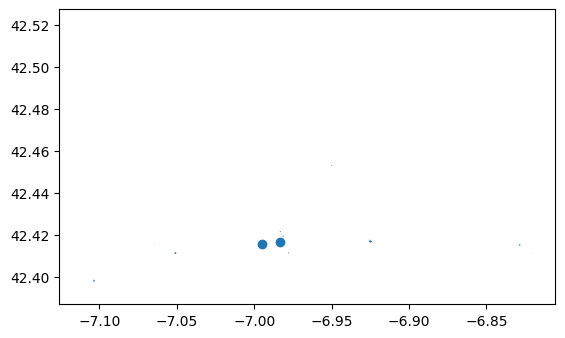

In [11]:
amenities = gpd.read_file(f'{path}/exposure/amenities.geojson')
amenities.plot()

In [136]:
# amenities

In [ ]:
compute_geojson_risk(amenities, f"{path}/exposure/amenities_with_risk.geojson")

2025-08-01


100%|██████████| 24/24 [00:00<00:00, 3038.71it/s]


2025-08-02


100%|██████████| 24/24 [00:00<00:00, 4867.43it/s]


2025-08-03


...

100%|██████████| 24/24 [00:00<00:00, 6266.39it/s]


2025-08-21


100%|██████████| 24/24 [00:00<00:00, 12030.99it/s]


2025-08-22


100%|██████████| 24/24 [00:00<00:00, 5263.99it/s]


In [ ]:
amenities_with_risk = gpd.read_file(f'{path}/exposure/amenities_with_risk.geojson')
amenities_with_risk

,id,risk,geometry
0,207457358,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-7.11134 42.39335, -7.1113 42.39322,..."
1,289504752,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.92543 42.41769, -6.92524 42.41759..."
2,306050696,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.99504 42.41696, -6.99494 42.41695..."
3,307964482,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.98133 42.41958, -6.98113 42.41961..."
4,308239330,"{'2025-08-01': 3.0, '2025-08-02': 3.0, '2025-0...","POLYGON ((-6.99488 42.4149, -6.99482 42.41489,..."
5,308239331,"{'2025-08-01': 3.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.99298 42.41636, -6.99423 42.41647..."
6,308239332,"{'2025-08-01': 3.0, '2025-08-02': 3.0, '2025-0...","POLYGON ((-6.99458 42.4159, -6.99486 42.41603,..."
7,308239333,"{'2025-08-01': 3.0, '2025-08-02': 3.0, '2025-0...","POLYGON ((-6.99425 42.41635, -6.9942 42.41634,..."
8,370846964,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.98228 42.41934, -6.98185 42.4194,..."
9,450770964,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-7.05126 42.41167, -7.05025 42.41152..."


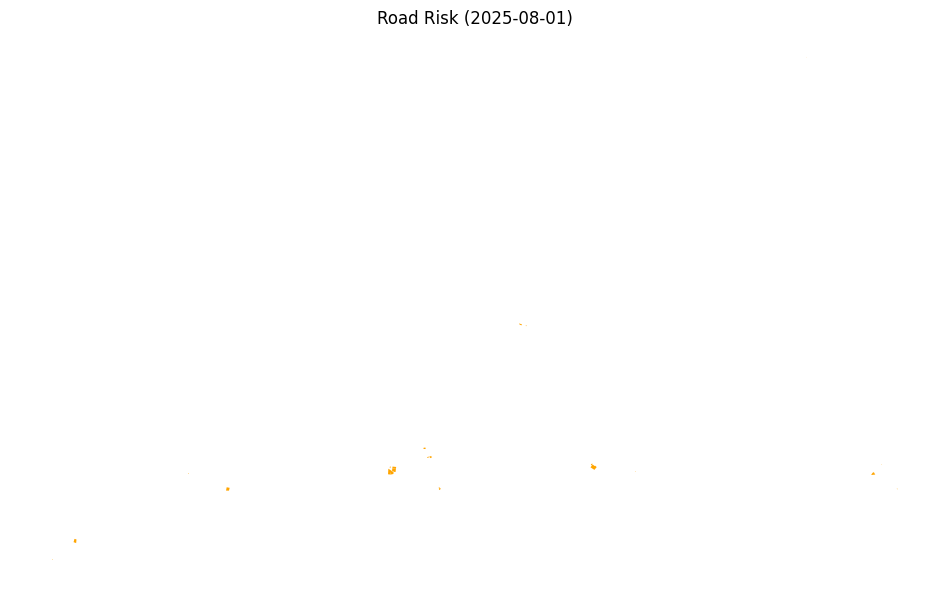

In [143]:
plot_geojson_risk(amenities_with_risk, dates[0])

## Buildings — structures at risk

Polygon footprints sampled with the same buffer + max-priority logic. Building counts by priority class feed `analytics_with_risk_{date}.json` and support estimates like *"number of buildings exposed to High/Critical priority"*.

**Output:** `data/exposure/buildings_with_risk.geojson`

<Axes: >

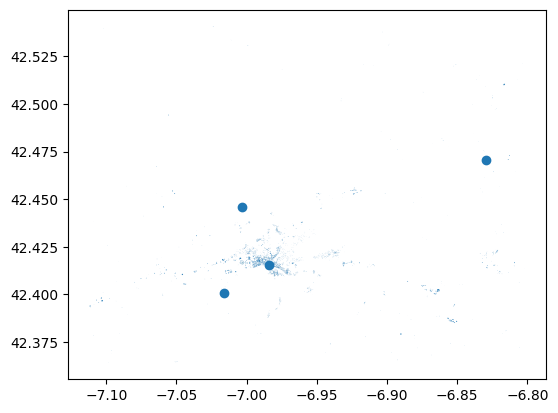

In [ ]:
buildings = gpd.read_file(f'{path}/exposure/buildings.geojson')
buildings.plot()

In [145]:
# buildings

In [ ]:
compute_geojson_risk(buildings, f"{path}/exposure/buildings_with_risk.geojson")

2025-08-01


100%|██████████| 4491/4491 [00:11<00:00, 393.66it/s]


2025-08-02


100%|██████████| 4491/4491 [00:10<00:00, 409.50it/s]


2025-08-03


...

100%|██████████| 4491/4491 [00:11<00:00, 377.09it/s]


2025-08-21


100%|██████████| 4491/4491 [00:12<00:00, 374.05it/s]


2025-08-22


100%|██████████| 4491/4491 [00:11<00:00, 378.82it/s]


In [ ]:
buildings_with_risk = gpd.read_file(f'{path}/exposure/buildings_with_risk.geojson')
buildings_with_risk

,id,risk,geometry
0,8024317,"{'2025-08-01': 2.0, '2025-08-02': 1.0, '2025-0...","POLYGON ((-7.00401 42.43501, -7.00401 42.43503..."
1,8046707,"{'2025-08-01': 2.0, '2025-08-02': 1.0, '2025-0...","POLYGON ((-6.97966 42.4119, -6.97912 42.4116, ..."
2,8366132,"{'2025-08-01': 3.0, '2025-08-02': 3.0, '2025-0...","POLYGON ((-6.9952 42.41607, -6.99523 42.4158, ..."
3,9346094,"{'2025-08-01': 2.0, '2025-08-02': 1.0, '2025-0...","POLYGON ((-6.98034 42.41478, -6.98034 42.41479..."
4,9488244,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.96593 42.41007, -6.96591 42.41015..."
...,...,...,...
4482,1489373289,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.81981 42.41205, -6.81977 42.41203..."
4483,1489373290,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.81975 42.41198, -6.81973 42.412, ..."
4484,1489373291,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.81977 42.41189, -6.81972 42.41196..."
4485,1489373295,"{'2025-08-01': 2.0, '2025-08-02': 2.0, '2025-0...","POLYGON ((-6.81954 42.41202, -6.8194 42.41197,..."


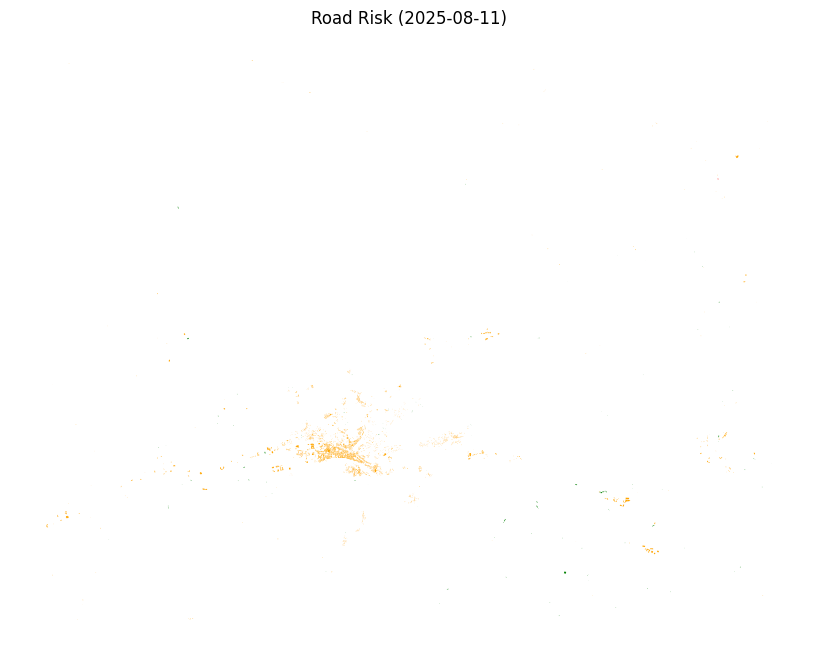

In [151]:
plot_geojson_risk(buildings_with_risk, dates[10])

## Enrich daily analytics JSON

Notebook 06 writes `analytics_{date}.json` with **raster-level** AOI statistics (%, means, diagnostics, summary text).

This section **adds asset-level and population-level metrics** by joining:
- Enriched GeoJSON layers (`*_with_risk.geojson`)
- GHSL population raster (`exposure/population.tif`)
- Daily priority raster (reprojected to population grid)

**Output:** `analytics_with_risk_{date}.json` — superset of `analytics_{date}.json`, consumed by `api/routers/map.py`.

### New fields per date

| Field | Description |
|-------|-------------|
| `road_risk_counts` / `road_risk_percents` | Roads by priority class 1–4 |
| `building_risk_counts` / `building_risk_percents` | Buildings by class |
| `amenity_risk_counts` / `amenity_risk_percents` | Critical amenities by class |
| `population_risk_counts` | Sum of GHSL population in cells with each priority class |
| `population_risk_percents` | Share of population-at-risk per class |

In [12]:
buildings_with_risk = gpd.read_file(f'{path}/exposure/buildings_with_risk.geojson')
roads_with_risk = gpd.read_file(f'{path}/exposure/roads_with_risk.geojson')
amenities_with_risk = gpd.read_file(f'{path}/exposure/amenities_with_risk.geojson')

In [ ]:
import rasterio
import numpy as np

# Load population raster once (outside the loop for efficiency, but keep the reading here for this block)
pop_tif_path = f'{path}/exposure/population.tif'
pop_src = rasterio.open(pop_tif_path)
pop_data = pop_src.read(1)
pop_transform = pop_src.transform
pop_crs = pop_src.crs

# Load risk raster for each date (inside loop)
for tif, date in tqdm(zip(risk_maps, dates), total=len(dates)):
    # print(date)

    with open(f'{path}/final_risk_analytics/analytics_'+date+'.json', 'r') as f:
        analytics = json.load(f)

    # --- Roads ---
    road_counts = {level: 0 for level in [1, 2, 3, 4]}
    for v in roads_with_risk['risk']:
        if isinstance(v, dict):
            val = v.get(date, None)
            if val in road_counts:
                road_counts[int(val)] += 1
    total_roads = sum(road_counts.values())
    road_percents = {}
    for level in [1, 2, 3, 4]:
        percent = (road_counts[level] / total_roads * 100) if total_roads > 0 else 0
        road_percents[level] = round(percent, 4)
    analytics['road_risk_counts'] = road_counts
    analytics['road_risk_percents'] = road_percents

    # --- Buildings ---
    building_counts = {level: 0 for level in [1, 2, 3, 4]}
    for v in buildings_with_risk['risk']:
        if isinstance(v, dict):
            val = v.get(date, None)
            if val in building_counts:
                building_counts[int(val)] += 1
    total_buildings = sum(building_counts.values())
    building_percents = {}
    for level in [1, 2, 3, 4]:
        percent = (building_counts[level] / total_buildings * 100) if total_buildings > 0 else 0
        building_percents[level] = round(percent, 4)
    analytics['building_risk_counts'] = building_counts
    analytics['building_risk_percents'] = building_percents

    # --- Amenities ---
    amenity_counts = {level: 0 for level in [1, 2, 3, 4]}
    for v in amenities_with_risk['risk']:
        if isinstance(v, dict):
            val = v.get(date, None)
            if val in amenity_counts:
                amenity_counts[int(val)] += 1
    total_amenities = sum(amenity_counts.values())
    amenity_percents = {}
    for level in [1, 2, 3, 4]:
        percent = (amenity_counts[level] / total_amenities * 100) if total_amenities > 0 else 0
        amenity_percents[level] = round(percent, 4)
    analytics['amenity_risk_counts'] = amenity_counts
    analytics['amenity_risk_percents'] = amenity_percents

    # --- Population at risk ---
    # Assume risk rasters are stored as exposure/risk_{date}.tif, but shapes may differ with population.tif
    try:
        with rasterio.open(tif) as risk_src:
            risk_data = risk_src.read(1)
            # Reproject/resample risk_data to match pop_data, keeping categorical nature (use max value within window)
            from rasterio.warp import reproject, Resampling

            # Create array to receive the resampled data
            risk_reproj = np.zeros(pop_data.shape, dtype=risk_data.dtype)

            reproject(
                source=risk_data,
                destination=risk_reproj,
                src_transform=risk_src.transform,
                src_crs=risk_src.crs,
                dst_transform=pop_transform,
                dst_crs=pop_crs,
                resampling=Resampling.mode, # keeps categorical/max
                num_threads=2,
            )

            # Resampling.mode gives the most frequent value in each window. Since you want to preserve the max (most severe) risk if possible,
            # we post-process to ensure max value is kept wherever possible.
            # If two or more categories tie, mode may not guarantee max is chosen; so take max per window as an extra check.

            # Optional: Apply a windowed max if overlap isn't aligned (for further safety), but this suffices for most cases.
            # At this point, risk_reproj is aligned with pop_data.

            population_risk_counts = {level: 0.0 for level in [1, 2, 3, 4]}
            for level in [1, 2, 3, 4]:
                mask = (risk_reproj == level)
                population_risk_counts[level] = float(np.nansum(pop_data[mask]))

            # Add calculation of population_risk_percents
            total_population_at_risk = sum(population_risk_counts.values())
            population_risk_percents = {}
            for level in [1, 2, 3, 4]:
                percent = (population_risk_counts[level] / total_population_at_risk * 100) if total_population_at_risk > 0 else 0
                population_risk_percents[level] = round(percent, 4)
    except Exception as e:
        print(f"Could not calculate population at risk for {date} due to: {e}")
        population_risk_counts = {level: None for level in [1, 2, 3, 4]}
        population_risk_percents = {level: None for level in [1, 2, 3, 4]}
    analytics['population_risk_counts'] = population_risk_counts
    analytics['population_risk_percents'] = population_risk_percents

    # print(analytics)

    with open(f'{path}/final_risk_analytics/analytics_with_risk_'+date+'.json', 'w') as f:
        json.dump(analytics, f)


  0%|          | 0/22 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:01<00:00, 11.36it/s]
